# QAOAでMaxCutを解く: 回路をゼロから構築する

このチュートリアルでは、Qamomileの低レベル回路プリミティブを使って、QAOA (Quantum Approximate Optimization Algorithm) のパイプラインをステップごとに構築します。高レベルな`QAOAConverter`は使わずに、以下の手順で進めます:

1. 小さなグラフでMaxCut問題を定義する。
2. スピン変数上のIsingモデルとして直接定式化する。
3. `@qkernel`を使ってQAOA回路をステップごとに記述する。
4. 古典オプティマイザで変分パラメータを最適化する。
5. 結果をデコードして可視化する。

最後に、`qamomile.circuit.algorithm.qaoa_state`が同じ回路を1つの関数呼び出しで提供することを示します。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

## MaxCut問題とは？

無向グラフ$G = (V, E)$が与えられたとき、**MaxCut**問題は頂点を2つの集合に分割し、2つの集合間を横切る辺の数を最大化する問題です。

MaxCutは本来、**スピン**変数で記述するのが自然な問題です。各頂点$i$にスピン$s_i \in \{+1, -1\}$を割り当て、頂点がどちら側に属するかを表現します。辺$(i, j)$が「カットされる」のは$s_i \ne s_j$のときなので、カットされる辺数は

$$
\text{MaxCut}(\boldsymbol{s})
= \sum_{(i,j) \in E} \frac{1 - s_i s_j}{2}
$$

と書けます。

MaxCutやスピングラス基底状態探索、Isingモデルベンチマークといったスピン変数で自然に定義される問題は、スピン領域で記述するのが最もクリーンです。そこで本チュートリアルではQUBO/バイナリ変数への寄り道は挟まず、最初から最後までスピン変数で扱います。

## グラフの作成

5頂点、6辺の小さなグラフを使います。全探索が可能な規模でありながら、自明でない構造を持っています。

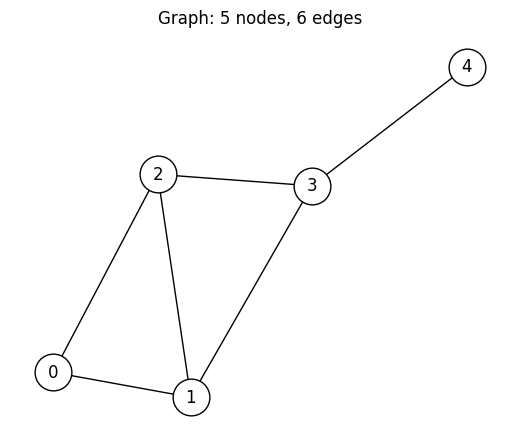

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Ising定式化

$\sum_{(i,j) \in E} (1 - s_i s_j) / 2$を最大化することは、定数を除いて以下の**反強磁性Isingハミルトニアン**を*最小化*することと等価です:

$$
H_C(\boldsymbol{s}) = \sum_{(i,j) \in E} s_i s_j.
$$

一般のIsing形式$H = \sum_i h_i s_i + \sum_{i < j} J_{ij} s_i s_j$と比較すると、重みなしMaxCutは以下の特徴を持ちます:

- **線形項なし**: 全頂点について$h_i = 0$
- **一様な相互作用**: 全辺$(i, j) \in E$について$J_{ij} = 1$

`BinaryModel.from_ising`はIsing係数を直接受け取ります。QUBOを経由して変数型を変換する必要はありません。

In [3]:
from qamomile.optimization.binary_model import BinaryModel

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}

# 重みつきMaxCutやスピングラスでは係数のスケールが揃っていないため、
# COBYLAなど勾配フリー最適化の収束を安定させる目的で
# `.normalize_by_abs_max()`を末尾に挟むとよい
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)

print(f"Variable type:          {spin_model.vartype}")
print(f"Linear terms (h_i):     {spin_model.linear}")
print(f"Quadratic terms (J_ij): {spin_model.quad}")
print(f"Constant:               {spin_model.constant}")

Variable type:          SPIN
Linear terms (h_i):     {}
Quadratic terms (J_ij): {(0, 1): 1.0, (0, 2): 1.0, (1, 2): 1.0, (1, 3): 1.0, (2, 3): 1.0, (3, 4): 1.0}
Constant:               0.0


> **Note:** `BinaryModel`はQUBO向けの`from_qubo()`や高次版の`from_hubo()`も提供しており、割当問題や制約（ペナルティ項）を伴う問題のようにバイナリ領域で自然に定式化される問題に利用できます。QUBO/JijModelingベースのワークフローについては[QAOAによるグラフ分割](../optimization/qaoa_graph_partition)を参照してください。

## 厳密解（全探索）

QAOAを実行する前に、すべての$2^n = 32$通りのスピン配置を試して最適な分割を求めておきます。QAOAの結果と比較するための基準になります。

In [4]:
import itertools

best_cut = 0
optimal_partitions: list[tuple[int, ...]] = []

for spins in itertools.product([+1, -1], repeat=num_nodes):
    cut = sum(1 for i, j in G.edges() if spins[i] != spins[j])
    if cut > best_cut:
        best_cut = cut
        optimal_partitions = [spins]
    elif cut == best_cut:
        optimal_partitions.append(spins)

print(f"Optimal MaxCut value: {best_cut}")
print(f"Number of optimal partitions: {len(optimal_partitions)}")
for part in optimal_partitions:
    print(f"  {part}")

Optimal MaxCut value: 5
Number of optimal partitions: 2
  (1, -1, -1, 1, -1)
  (-1, 1, 1, -1, 1)


## QAOA回路: 基本的な考え方

QAOAのアンザッツはパラメータ付き量子状態を準備します:

$$
|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle
= \prod_{l=1}^{p}
  e^{-i \beta_l H_M} \, e^{-i \gamma_l H_C}
  \; |{+}\rangle^{\otimes n}
$$

ここで:

- $|{+}\rangle^{\otimes n}$: 一様重ね合わせ（全量子ビットにHadamardゲート）
- $e^{-i \gamma H_C}$: **コストユニタリ** — Isingコスト$H_C$の場合、二次項は$\text{RZZ}$ゲート、一次項は$\text{RZ}$ゲートに分解されます（ゲートの規約についてはステップ2–3を参照）
- $e^{-i \beta H_M}$: **ミキサーユニタリ** — $H_M = \sum_i X_i$の場合、各量子ビットへの$\text{RX}(2\beta)$になります
- $p$: レイヤー数（アンザッツの深さ）

スピンと計算基底の対応は量子力学の標準的な規約$Z|0\rangle = |0\rangle$, $Z|1\rangle = -|1\rangle$に従います。すなわち、測定結果$0$はスピン$+1$、測定結果$1$はスピン$-1$に対応します。

各コンポーネントを`@qkernel`として実装していきます。

### ステップ1: 一様重ね合わせ

全量子ビットにHadamardゲートを適用し、均等な重ね合わせ状態$|{+}\rangle^{\otimes n}$を作ります。

In [5]:
import qamomile.circuit as qmc


@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q

### ステップ2: コスト層

コストユニタリ$e^{-i \gamma H_C}$を適用します。

Qamomileの回転ゲートは$1/2$の因子を含む規約を使います: $\text{RZ}(\theta) = e^{-i \theta Z / 2}$、$\text{RZZ}(\theta) = e^{-i \theta Z \otimes Z / 2}$。$e^{-i \gamma H_C}$と厳密に一致させるには角度を$2 J_{ij} \gamma$とすべきですが、$\gamma$は古典オプティマイザが自由に調整する**変分パラメータ**であるため、この定数倍は最適な$\gamma$の値に吸収されます。したがって、$J_{ij} \cdot \gamma$（および$h_i \cdot \gamma$）をそのまま渡します。

重みなしMaxCutでは`linear`引数は空ですが、そのまま引数として残しておきます。こうすることで、線形項$h_i$を持つ重みつきMaxCutや一般のスピングラスハミルトニアンにそのまま流用できます。

In [6]:
@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q

### ステップ3: ミキサー層

ミキサーユニタリ$e^{-i \beta H_M}$を適用します（$H_M = \sum_i X_i$）。$\text{RX}(\theta) = e^{-i \theta X / 2}$なので、$e^{-i \beta X_i}$を実装するには$\theta = 2\beta$とします。

In [7]:
@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q

### ステップ4: 完全なQAOAアンザッツ

3つの要素を組み合わせます: 重ね合わせ → $p$ラウンドのコスト層 + ミキサー層 → 測定。

In [8]:
@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

## トランスパイルと最適化

カーネルをトランスパイルします。問題の構造（Ising係数、量子ビット数、レイヤー数）はバインドし、`gammas`と`betas`はオプティマイザがチューニングするランタイムパラメータとして残します。

In [9]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 3  # QAOAレイヤー数

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`scipy.optimize.minimize`のCOBYLA法を使います。各反復で回路をサンプリングし、平均エネルギーを評価します。

In [10]:
import os
import numpy as np
from scipy.optimize import minimize

executor = transpiler.executor()
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 20 if docs_test_mode else 500
cost_history: list[float] = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    result = executable.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    ).result()
    decoded = spin_model.decode_from_sampleresult(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


rng = np.random.default_rng(42)
initial_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)

res = minimize(cost_fn, initial_params, method="COBYLA", options={"maxiter": maxiter})

print(f"Optimized cost: {res.fun:.4f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")

Optimized cost: -2.7871
Optimal params: [np.float64(0.9344), np.float64(-0.3959), np.float64(1.4097), np.float64(0.4343), np.float64(-0.9092), np.float64(2.8393)]


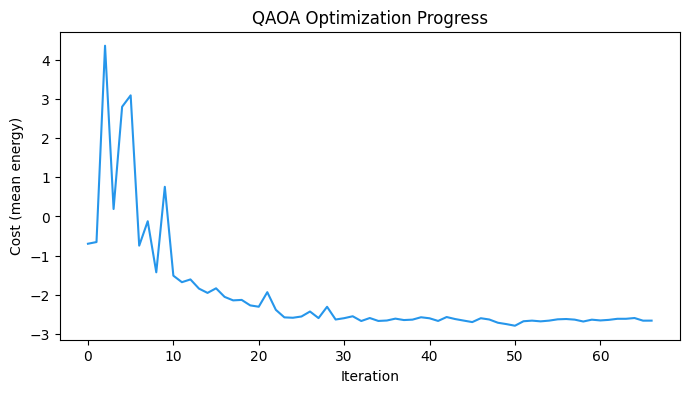

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("QAOA Optimization Progress")
plt.show()

## 結果のデコードと分析

最適化されたパラメータで回路をサンプリングし、測定結果を解釈します。`decode_from_sampleresult`はスピン領域（+1 / -1）のサンプルを返すので、バイナリ変換を挟まずに直接カット辺数を数えられます。

In [12]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

final_result = executable.sample(
    executor,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded = spin_model.decode_from_sampleresult(final_result)

In [13]:
from collections import Counter

cut_distribution: Counter[int] = Counter()
best_qaoa_cut = 0
best_qaoa_sample = None

for sample, _energy, occ in zip(
    decoded.samples, decoded.energy, decoded.num_occurrences
):
    # sampleは{頂点インデックス: スピン値 (+1 or -1)}の辞書
    spins = [sample[i] for i in range(num_nodes)]
    cut = sum(1 for i, j in G.edges() if spins[i] != spins[j])
    cut_distribution[cut] += occ
    if cut > best_qaoa_cut:
        best_qaoa_cut = cut
        best_qaoa_sample = spins

print(f"Best QAOA cut: {best_qaoa_cut}  (optimal: {best_cut})")
print(f"Best partition (spins): {best_qaoa_sample}")

Best QAOA cut: 5  (optimal: 5)
Best partition (spins): [1, -1, -1, 1, -1]


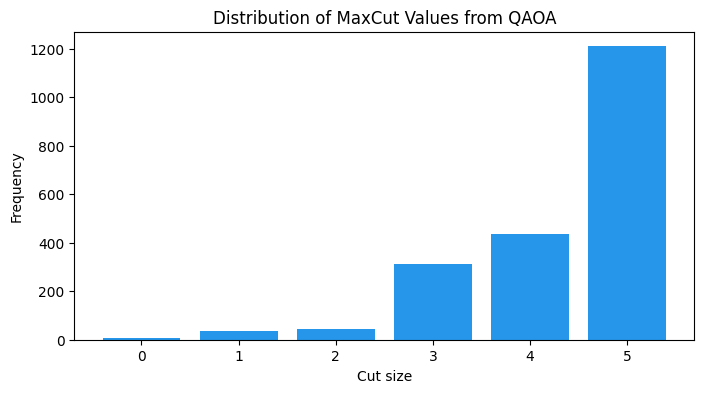

In [14]:
cuts = sorted(cut_distribution.keys())
counts = [cut_distribution[c] for c in cuts]

plt.figure(figsize=(8, 4))
plt.bar([str(c) for c in cuts], counts, color="#2696EB")
plt.xlabel("Cut size")
plt.ylabel("Frequency")
plt.title("Distribution of MaxCut Values from QAOA")
plt.show()

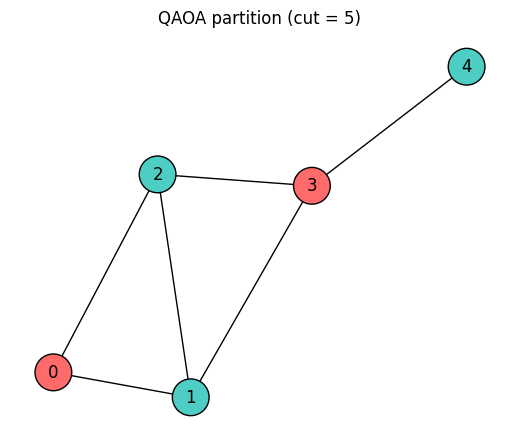

In [15]:
if best_qaoa_sample is not None:
    color_map = [
        "#FF6B6B" if best_qaoa_sample[i] == +1 else "#4ECDC4"
        for i in range(num_nodes)
    ]
    plt.figure(figsize=(5, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=700,
        edgecolors="black",
    )
    plt.title(f"QAOA partition (cut = {best_qaoa_cut})")
    plt.show()

## 組み込みの`qaoa_state`を使う

上で実装したすべて — 重ね合わせ、コスト層、ミキサー層、レイヤーのループ — は`qamomile.circuit.algorithm.qaoa_state`として既に提供されています。同じIsing係数（`quad`, `linear`）と変分パラメータ（`gammas`, `betas`）を受け取ります。

組み込み関数を使って同じ構造の回路が実装されていることを確認します。環境依存を避けるため、ここでも既定のローカルexecutorを使います。

In [16]:
from qamomile.circuit.algorithm import qaoa_state


@qmc.qkernel
def qaoa_builtin(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)

同じ最適化済みパラメータでトランスパイル・サンプリングします。

In [17]:
exe_builtin = transpiler.transpile(
    qaoa_builtin,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

executor_manual = transpiler.executor()
executor_builtin = transpiler.executor()

result_manual = executable.sample(
    executor_manual,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

result_builtin = exe_builtin.sample(
    executor_builtin,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded_manual = spin_model.decode_from_sampleresult(result_manual)
decoded_builtin = spin_model.decode_from_sampleresult(result_builtin)
print(f"Manual   mean energy: {decoded_manual.energy_mean():.4f}")
print(f"Built-in mean energy: {decoded_builtin.energy_mean():.4f}")

Manual   mean energy: -2.6924
Built-in mean energy: -2.6338


## まとめ

このチュートリアルでは:

1. MaxCut問題を定義し、QUBO/バイナリ変数を経由せずに*直接*スピン変数上のIsingハミルトニアンとして記述しました。
2. `BinaryModel.from_ising`でスピン領域の`BinaryModel`を構築しました。
3. QAOA回路の全コンポーネント — 重ね合わせ、コスト層、ミキサー層、完全なアンザッツ — を`@qkernel`として実装しました。
4. 古典最適化ループを実行し、スピン領域のまま結果をデコードしました。
5. `qamomile.circuit.algorithm.qaoa_state`が同じ回路を1つの関数呼び出しで提供することを確認しました。

この「スピンから始める」レシピは、スピングラス基底状態探索、重みつきMaxCut、Sherrington–Kirkpatrickモデルといった任意のIsing型問題にそのまま適用できます。$h_i$と$J_{ij}$を`BinaryModel.from_ising`に渡し、上で作成した回路コンポーネントを再利用するだけです。

**次のステップ:**

- **バイナリ変数**で自然に定式化される問題や、**制約**（ペナルティ項）が必要な問題については、JijModelingと高レベルの`QAOAConverter`を使う[QAOAによるグラフ分割](../optimization/qaoa_graph_partition)を参照してください。